### PySpark Otomoto Demo 

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023 


In [ ]:
!conda install -y pyspark

In [1]:
import pyspark
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

print(pyspark.__version__)
print(os.environ.get("JAVA_HOME"))

from pyspark.sql import SparkSession

import shutil

print(shutil.which("java"))

import subprocess

result = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True
)

print(result.returncode)
print(result.stderr)

import shutil

print("java =", shutil.which("java"))

import platform

print(platform.architecture())

spark = SparkSession.builder \
    .master("local[1]") \
    .appName("test") \
    .getOrCreate()

print("Spark działa")

4.1.1
C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot
C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot\bin\java.EXE
0
openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment Temurin-17.0.19+10 (build 17.0.19+10)
OpenJDK 64-Bit Server VM Temurin-17.0.19+10 (build 17.0.19+10, mixed mode, sharing)

java = C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot\bin\java.EXE
('64bit', 'WindowsPE')
Spark działa


In [12]:
import os
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [13]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Otomoto Demo") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.bindAddress", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

print("Sukces! Spark przebił się przez sieć uczelni!")


Sukces! Spark przebił się przez sieć uczelni!


**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [14]:
df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [15]:
df.show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [16]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [17]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [18]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [19]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka
+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows


In [20]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [21]:
df.createOrReplaceTempView("cars")

In [22]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [23]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [24]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [25]:
# zależność ceny od przebiegu 
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


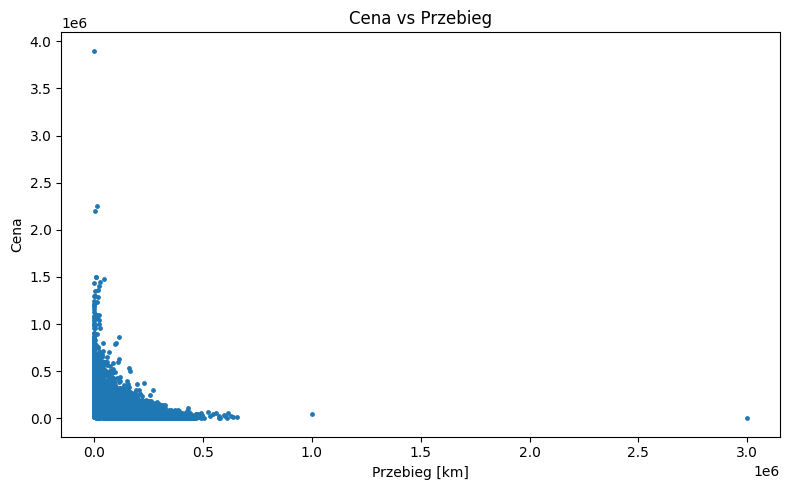

In [26]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [42]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, hour, to_timestamp,
    dayofweek, month, count
)

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler, StringIndexer
)
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from pyspark.mllib.evaluation import MulticlassMetrics

# =========================
# 1. SPARK START
# =========================
spark = SparkSession.builder \
    .appName("Chicago Crimes A+ Model") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Spark OK")

# =========================
# 2. LOAD DATA
# =========================
df = spark.read.csv(
    "chicago_crimes_sample.csv",
    header=True,
    inferSchema=True
)

# =========================
# 3. CLEAN DATA
# =========================
df = df.dropna(subset=[
    "id", "date", "primary_type",
    "location_description", "year"
]).dropDuplicates(["id"])

# timestamp
df = df.withColumn(
    "DateTS",
    to_timestamp("date", "yyyy-MM-dd HH:mm:ss")
).filter(col("DateTS").isNotNull())

# =========================
# 4. FEATURE ENGINEERING (A+ LEVEL)
# =========================

df = df.withColumn("Hour", hour("DateTS"))
df = df.withColumn("DayOfWeek", dayofweek("DateTS"))
df = df.withColumn("Month", month("DateTS"))

# time of day
df = df.withColumn(
    "TimeOfDay",
    when(col("Hour") < 6, 0)
    .when(col("Hour") < 12, 1)
    .when(col("Hour") < 18, 2)
    .otherwise(3)
)

# binary arrest
df = df.withColumn(
    "arrest_num",
    when(col("arrest") == True, 1).otherwise(0)
)

# fill nulls
df = df.fillna({
    "location_description": "UNKNOWN",
    "primary_type": "UNKNOWN"
})

# =========================
# 5. INDEXING
# =========================
location_indexer = StringIndexer(
    inputCol="location_description",
    outputCol="location_index",
    handleInvalid="keep"
)

label_indexer = StringIndexer(
    inputCol="primary_type",
    outputCol="label",
    handleInvalid="keep"
)

# =========================
# 6. FEATURE VECTOR
# =========================
assembler = VectorAssembler(
    inputCols=[
        "Hour",
        "DayOfWeek",
        "Month",
        "TimeOfDay",
        "arrest_num"
    ],
    outputCol="features"
)

# =========================
# 7. MODEL (GBT - LEPSZY NIŻ RF)
# =========================

df = df.withColumn(
    "label_binary",
    when(col("primary_type") == "THEFT", 1).otherwise(0)
)

gbt = GBTClassifier(
    labelCol="label_binary",
    featuresCol="features",
    maxIter=50,
    maxDepth=6
)

# =========================
# 8. PIPELINE
# =========================
pipeline = Pipeline(stages=[
    location_indexer,
    label_indexer,
    assembler,
    gbt
])

# =========================
# 9. TRAIN / TEST
# =========================
train, test = df.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train)
predictions = model.transform(test)

# =========================
# 10. EVALUATION (ACCURACY + F1)
# =========================
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

accuracy = evaluator_acc.evaluate(predictions)
f1 = evaluator_f1.evaluate(predictions)

print("Accuracy:", accuracy)
print("F1-score:", f1)

# =========================
# 11. CONFUSION MATRIX (STABLE VERSION)
# =========================

conf_matrix_pivot = predictions.groupBy("label") \
    .pivot("prediction") \
    .count() \
    .fillna(0)

conf_matrix_pivot.show(50, False)

Spark OK
Accuracy: 0.2199460377735585
F1-score: 0.07935138448060552
+-----+----+---+
|label|0.0 |1.0|
+-----+----+---+
|7.0  |528 |0  |
|12.0 |76  |0  |
|6.0  |634 |0  |
|13.0 |62  |0  |
|22.0 |5   |0  |
|4.0  |832 |0  |
|1.0  |1849|0  |
|17.0 |16  |0  |
|20.0 |14  |0  |
|21.0 |6   |0  |
|9.0  |231 |0  |
|29.0 |1   |0  |
|26.0 |1   |0  |
|23.0 |8   |0  |
|8.0  |287 |0  |
|14.0 |62  |0  |
|25.0 |2   |0  |
|0.0  |2201|1  |
|10.0 |201 |0  |
|18.0 |14  |0  |
|16.0 |37  |0  |
|19.0 |22  |0  |
|3.0  |893 |0  |
|24.0 |2   |0  |
|2.0  |1091|0  |
|5.0  |675 |1  |
|11.0 |194 |0  |
|15.0 |61  |0  |
+-----+----+---+

